# Phase 5 — Notebook 19: Cost, Latency & False-Positive Accounting (Objective 7)

The operational accounting. nb18 measured recall only and left one question load-bearing:
the `triggered` detector trains on a tiny accumulated pool (≤ ~6,750 flows) — **does it flood
the operator with benign false positives?** Here we re-run the policies with full
confusion-matrix instrumentation and report, per policy, the three operational axes:

- **Labels** (human cost) — from nb18, re-confirmed.
- **Compute** (machine cost) — total retrain wall-time.
- **False positives** (operator triage burden) — FPR and total alert volume. *The new metric.*

plus recall/precision for the quality side, and the headline trade-off sentence.

**Reference for the FPR question.** `always_sliding` (retrains every window on the full 50k
window) is the fair comparison: it isolates the *budget* effect — same retrain frequency as
`triggered`, but full labels vs 250. `cumulative` is the heavy true ceiling and is **off by
default** here (`RUN_CUMULATIVE=False`); flip it on for the full upper bound.

Reuses `src/adaptation/policies.py` semantics via an instrumented loop written to
`src/adaptation/cost_eval.py` (recall reproduces nb18 as a consistency check).

## Pre-registration (D037)

**Setup.** Same stream, windows, frozen detector and `tau` as nb18 (full data, no
subsampling). Re-run never / always-sliding / periodic / triggered-B (+ cumulative if
enabled) with per-window confusion counts, retrain wall-time, and labels.

**Metrics (micro-averaged over drift windows).** recall, precision, **FPR = fp/(fp+tn)**,
F1; total labels; total compute (s); **alert volume = total false positives** over the stream.

**Reference.** `always_sliding` is the full-label retrainer the cheap `triggered` is judged
against (isolates the budget effect on false positives).

**Gates** (verdict `COST-ACCOUNTING-VALID` iff all hold), headline budget = smallest:

- **G1 — FP acceptable:** `triggered` FPR `<= always_sliding` FPR `+ FPR_MARGIN` (the small
  budget does not materially inflate false positives).
- **G2 — compute saving:** `triggered` total compute `< always_sliding` total compute.
- **G3 — joint headline:** `triggered` recall `>= always_sliding` recall `- RECALL_MARGIN`
  **and** FPR within `FPR_MARGIN` **and** labels `<= COST_FRAC_MAX × always_sliding` labels.
- **G4 — deterministic.**

If the cheap detector's FPR blows up, G1/G3 fail — that is the real Objective-7 finding, reported,
not tuned away.

In [1]:
# --- Environment ---
import sys
from pathlib import Path
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except Exception:
    pass

THESIS_ROOT = Path('/content/drive/MyDrive/phd_thesis')
if str(THESIS_ROOT) not in sys.path:
    sys.path.insert(0, str(THESIS_ROOT))

import numpy as np, pandas as pd, json, time
from datetime import date
import matplotlib.pyplot as plt

from src.utils.seeding import set_global_seed
from src.utils.io import path
from src.data.loaders import load_cicids2017
from src.utils.documentation import log_finding
from src.streaming.replay import train_detector
from src.monitoring.ks_monitor import KSMonitor

SEED = 42
set_global_seed(SEED)

# --- Pre-registered configuration (D037; matches nb18) ---
WINDOW_SIZE = 50_000
TRAIN_DAYS  = ['monday', 'tuesday']
STREAM_DAYS = ['wednesday', 'thursday', 'friday']
RF_KW = dict(n_estimators=100, max_depth=12, random_state=SEED, n_jobs=-1)
REF_FRAC = 0.50
K_SIGMA = 3.0
BUDGET_GRID = [250, 2500, 25000]
PERIODIC_K  = 3
RUN_CUMULATIVE = False    # heavy true ceiling; off by default (always_sliding is the FPR ref)
# Gate thresholds
FPR_MARGIN    = 0.05
RECALL_MARGIN = 0.05
COST_FRAC_MAX = 0.50
print('Config set. SEED =', SEED, '| RUN_CUMULATIVE =', RUN_CUMULATIVE)

Mounted at /content/drive
Config set. SEED = 42 | RUN_CUMULATIVE = False


In [2]:
# --- Load, build the stream, frozen detector, tau (same as nb18) ---
def load_days(days):
    Xs, ms = [], []
    for d in days:
        X, _y, meta = load_cicids2017(day=d)
        Xs.append(X.astype('float32')); ms.append(meta)
    return (pd.concat(Xs, ignore_index=True).reset_index(drop=True),
            pd.concat(ms, ignore_index=True).reset_index(drop=True))

def families(meta):
    return meta['attack_category'].astype(str).str.lower().to_numpy()

def windows_of(n, size):
    b = list(range(0, n, size)) + [n]
    return [(b[i], b[i + 1]) for i in range(len(b) - 1)]

X_tr, meta_tr = load_days(TRAIN_DAYS)
y_tr = (families(meta_tr) != 'benign').astype(int)
train_families = set(np.unique(families(meta_tr))) - {'benign'}

X_st, meta_st = load_days(STREAM_DAYS)
assert list(X_tr.columns) == list(X_st.columns), 'feature schema mismatch'
Xstream = X_st.to_numpy()
ystream = (families(meta_st) != 'benign').astype(int)
fam_stream = families(meta_st)
strm_windows = windows_of(len(Xstream), WINDOW_SIZE)

def novel_rate(fam_slice):
    return float(np.mean([(f not in train_families) and (f != 'benign') for f in fam_slice]))
is_drift = [novel_rate(fam_stream[a:b]) > 0 for (a, b) in strm_windows]

t0 = time.time()
det0 = train_detector(X_tr.to_numpy(), y_tr, RF_KW)
print(f'Frozen detector trained on {len(X_tr):,} rows in {time.time() - t0:.1f}s')

rng = np.random.default_rng(SEED)
perm = rng.permutation(len(X_tr)); n_ref = int(REF_FRAC * len(X_tr))
REF = X_tr.to_numpy()[perm[:n_ref]]; Xcal = X_tr.to_numpy()[perm[n_ref:]]
monitor = KSMonitor(REF)
monitor.calibrate([Xcal[a:b] for (a, b) in windows_of(len(Xcal), WINDOW_SIZE)], k=K_SIGMA)
TAU = monitor.tau
print(f'Stream {len(Xstream):,} rows -> {len(strm_windows)} windows; '
      f'drift windows {sum(is_drift)}; tau = {TAU:.4f}')

Frozen detector trained on 693,699 rows in 24.2s
Stream 1,406,272 rows -> 29 windows; drift windows 29; tau = 0.0036


In [3]:
# --- Promote the instrumented runner to src/adaptation/cost_eval.py (shared by nb 20) ---
ad_dir = THESIS_ROOT / 'src' / 'adaptation'
ad_dir.mkdir(parents=True, exist_ok=True)
ce_lines = [
    '"""',
    'Instrumented policy runner for the Phase-5 cost/latency accounting (Objective 7).',
    '',
    'Re-expresses the notebook-18 policies in a single loop that records, per window,',
    'the full confusion counts (tp/fp/fn/tn), the retrain wall-time, and the labels',
    'spent -- so recall, precision, false-positive rate, alert volume, compute, and',
    'labels all come from one pass. The retrain SEMANTICS match policies.py exactly',
    '(always/cumulative/periodic retrain before scoring window i; triggered scores',
    'then retrains with an updating reference), so recall reproduces notebook 18.',
    '',
    'Promoted from notebook 19 for notebook 20.',
    '"""',
    'from __future__ import annotations',
    'import time',
    'import numpy as np',
    'from src.streaming.replay import train_detector',
    'from src.monitoring.ks_monitor import per_feature_ks',
    '',
    '',
    'def confusion(y_true, y_pred):',
    '    yt = np.asarray(y_true); yp = np.asarray(y_pred)',
    '    tp = int(((yp == 1) & (yt == 1)).sum())',
    '    fp = int(((yp == 1) & (yt == 0)).sum())',
    '    fn = int(((yp == 0) & (yt == 1)).sum())',
    '    tn = int(((yp == 0) & (yt == 0)).sum())',
    '    return tp, fp, fn, tn',
    '',
    '',
    'def run_instrumented(Xs, ys, windows, det0, rf_kw, policy,',
    '                     reference0=None, tau=None, budget=None, K=None, seed=42):',
    '    """Run one policy with full per-window instrumentation.',
    '',
    "    policy in {'never','always_sliding','cumulative','periodic','triggered'}.",
    '    Returns per-window confusion + retrain time + labels, plus totals.',
    '    """',
    '    rng = np.random.default_rng(seed)',
    '    rows = []',
    '    labels = 0',
    '    compute = 0.0',
    '    cur = det0',
    '    ref = None if reference0 is None else np.asarray(reference0)',
    '    poolX, poolY, triggers = [], [], []',
    '',
    '    for i, (a, b) in enumerate(windows):',
    '        Xi, yi = Xs[a:b], ys[a:b]',
    '        rt = 0.0',
    '        spent = 0',
    '        # retrain BEFORE scoring (always / cumulative / periodic)',
    "        if policy == 'always_sliding' and i > 0:",
    '            aa, bb = windows[i - 1][0], windows[i][0]',
    '            t = time.time(); cur = train_detector(Xs[aa:bb], ys[aa:bb], rf_kw); rt = time.time() - t',
    '            spent = bb - aa',
    "        elif policy == 'cumulative' and i > 0:",
    '            bb = windows[i][0]',
    '            t = time.time(); cur = train_detector(Xs[0:bb], ys[0:bb], rf_kw); rt = time.time() - t',
    '            spent = bb',
    "        elif policy == 'periodic' and i > 0 and (i % K == 0):",
    '            aa, bb = windows[i - 1][0], windows[i][0]',
    '            t = time.time(); cur = train_detector(Xs[aa:bb], ys[aa:bb], rf_kw); rt = time.time() - t',
    '            spent = bb - aa',
    '',
    '        tp, fp, fn, tn = confusion(yi, cur.predict(Xi))   # score window i',
    '',
    '        # triggered: score-then-maybe-retrain, updating reference',
    "        if policy == 'triggered':",
    '            score = float(per_feature_ks(ref, Xi).mean())',
    '            if score > tau:',
    '                triggers.append(i)',
    '                k = min(budget, len(Xi))',
    '                idx = rng.choice(len(Xi), size=k, replace=False)',
    '                poolX.append(Xi[idx]); poolY.append(yi[idx])',
    '                t = time.time()',
    '                cur = train_detector(np.concatenate(poolX), np.concatenate(poolY), rf_kw)',
    '                rt = time.time() - t',
    '                spent = k',
    '                ref = Xi',
    '',
    '        labels += spent; compute += rt',
    '        rows.append(dict(window=i, tp=tp, fp=fp, fn=fn, tn=tn,',
    '                         retrained=(spent > 0), retrain_s=rt, labels=spent))',
    '',
    "    name = policy if policy != 'triggered' else f'triggered_{budget}'",
    '    return dict(policy=name, per_window=rows, label_cost=labels,',
    "                compute_s=compute, n_retrains=sum(r['retrained'] for r in rows),",
    '                triggers=triggers)',
    '',
    '',
    'def micro_metrics(rows, mask=None):',
    '    """Micro-averaged recall / precision / FPR / F1 over selected windows."""',
    '    sel = rows if mask is None else [r for r, m in zip(rows, mask) if m]',
    "    tp = sum(r['tp'] for r in sel); fp = sum(r['fp'] for r in sel)",
    "    fn = sum(r['fn'] for r in sel); tn = sum(r['tn'] for r in sel)",
    "    rec = tp / (tp + fn) if (tp + fn) else float('nan')",
    "    prec = tp / (tp + fp) if (tp + fp) else float('nan')",
    "    fpr = fp / (fp + tn) if (fp + tn) else float('nan')",
    "    f1 = (2 * prec * rec / (prec + rec)) if (prec + rec) else float('nan')",
    '    return dict(recall=rec, precision=prec, fpr=fpr, f1=f1,',
    '                tp=tp, fp=fp, fn=fn, tn=tn)',
    ''
]
ce_src = '\n'.join(ce_lines)
(ad_dir / 'cost_eval.py').write_text(ce_src)

import importlib
import src.adaptation.cost_eval as _ce
importlib.reload(_ce)
from src.adaptation.cost_eval import run_instrumented, micro_metrics
print(f'Wrote src/adaptation/cost_eval.py ({len(ce_lines)} lines) and imported it.')

Wrote src/adaptation/cost_eval.py (99 lines) and imported it.


In [4]:
# --- Run all policies with full instrumentation ---
Xs, ys = Xstream, ystream
runs = []

def go(label, **kw):
    t = time.time()
    r = run_instrumented(Xs, ys, strm_windows, det0, RF_KW, **kw)
    print(f"  {r['policy']:18s} wall {time.time()-t:6.1f}s  "
          f"compute {r['compute_s']:6.1f}s  labels {r['label_cost']:>9,}  "
          f"retrains {r['n_retrains']}")
    runs.append(r)

print('Running instrumented policies...')
go('never', policy='never')
go('always_sliding', policy='always_sliding')
go('periodic', policy='periodic', K=PERIODIC_K)
if RUN_CUMULATIVE:
    go('cumulative', policy='cumulative')
for B in BUDGET_GRID:
    go(f'triggered_{B}', policy='triggered', reference0=REF, tau=TAU, budget=B)
print('Done.')

Running instrumented policies...
  never              wall    1.5s  compute    0.0s  labels         0  retrains 0
  always_sliding     wall   37.5s  compute   36.0s  labels 1,400,000  retrains 28
  periodic           wall   13.0s  compute   11.5s  labels   450,000  retrains 9
  triggered_250      wall   36.9s  compute    6.9s  labels     6,750  retrains 27
  triggered_2500     wall   68.7s  compute   38.6s  labels    67,500  retrains 27
  triggered_25000    wall  610.7s  compute  580.3s  labels   656,272  retrains 27
Done.


In [5]:
# --- Operational accounting table, gates, save ---
res = {r['policy']: r for r in runs}
total_flows = sum(len(ys[a:b]) for (a, b) in strm_windows)

rows = []
for name, r in res.items():
    m = micro_metrics(r['per_window'], mask=is_drift)          # over drift windows
    mall = micro_metrics(r['per_window'])                       # over all windows
    rows.append(dict(policy=name,
                     recall=m['recall'], precision=m['precision'], fpr=m['fpr'], f1=m['f1'],
                     alert_volume_fp=mall['fp'],
                     label_cost=r['label_cost'], compute_s=round(r['compute_s'], 1),
                     n_retrains=r['n_retrains']))
acct = pd.DataFrame(rows).sort_values('label_cost').reset_index(drop=True)

ref_pol = 'always_sliding'
refm = micro_metrics(res[ref_pol]['per_window'], mask=is_drift)
ref_labels = res[ref_pol]['label_cost'] or 1
ref_compute = res[ref_pol]['compute_s'] or 1e-9
hb = f'triggered_{min(BUDGET_GRID)}'
hm = micro_metrics(res[hb]['per_window'], mask=is_drift)

# Gates
g1_fp = bool(hm['fpr'] <= refm['fpr'] + FPR_MARGIN)
g2_compute = bool(res[hb]['compute_s'] < res[ref_pol]['compute_s'])
g3_joint = bool((hm['recall'] >= refm['recall'] - RECALL_MARGIN) and
                (hm['fpr'] <= refm['fpr'] + FPR_MARGIN) and
                (res[hb]['label_cost'] <= COST_FRAC_MAX * ref_labels))
r_chk = run_instrumented(Xs, ys, strm_windows, det0, RF_KW, policy='never')
g4_determ = bool(micro_metrics(r_chk['per_window'])['fp'] ==
                 micro_metrics(res['never']['per_window'])['fp'])
verdict = ('COST-ACCOUNTING-VALID'
           if (g1_fp and g2_compute and g3_joint and g4_determ)
           else 'COST-ACCOUNTING-CHECK-FAILED')

# nb18 cumulative recall ceiling for context (if available)
ceil_ctx = None
try:
    j = json.load(open(path('data', 'processed', 'phase5_18_triggered_retraining.json')))
    ceil_ctx = j.get('ceiling_recall_drift')
except Exception:
    pass

headline = (f"{hb}: recall {hm['recall']:.3f}, FPR {hm['fpr']:.4f} "
            f"({hm['fp']:,} alerts), {res[hb]['label_cost']:,} labels, "
            f"{res[hb]['compute_s']:.0f}s compute — vs {ref_pol} recall {refm['recall']:.3f}, "
            f"FPR {refm['fpr']:.4f}, {ref_labels:,} labels, {res[ref_pol]['compute_s']:.0f}s "
            f"(labels {res[hb]['label_cost']/ref_labels:.2%}, compute "
            f"{res[hb]['compute_s']/ref_compute:.2%}).")

summary = dict(
    notebook='19_cost_latency', decision='D037', finding='F025',
    generated=str(date.today()), seed=SEED, dataset='CICIDS2017',
    window_size=WINDOW_SIZE, n_windows=len(strm_windows), total_flows=total_flows,
    tau=TAU, budget_grid=BUDGET_GRID, run_cumulative=RUN_CUMULATIVE,
    reference_policy=ref_pol, nb18_cumulative_recall_ceiling=ceil_ctx,
    accounting=acct.to_dict(orient='records'),
    headline=headline,
    gates=dict(g1_fp=g1_fp, g2_compute=g2_compute, g3_joint=g3_joint,
               g4_determinism=g4_determ, FPR_MARGIN=FPR_MARGIN,
               RECALL_MARGIN=RECALL_MARGIN, COST_FRAC_MAX=COST_FRAC_MAX),
    verdict=verdict,
)

path('reports', 'tables').mkdir(parents=True, exist_ok=True)
path('data', 'processed').mkdir(parents=True, exist_ok=True)
acct.to_csv(path('reports', 'tables', '19_cost_accounting.csv'), index=False)
with open(path('data', 'processed', 'phase5_19_cost_latency.json'), 'w') as f:
    json.dump(summary, f, indent=2)

pd.set_option('display.float_format', lambda v: f'{v:.4f}')
print(acct.to_string(index=False))
print('\nverdict:', verdict)
print('headline:', headline)
if ceil_ctx is not None:
    print(f'(nb18 cumulative recall ceiling for context: {ceil_ctx:.3f})')

         policy  recall  precision    fpr     f1  alert_volume_fp  label_cost  compute_s  n_retrains
          never  0.0000        NaN 0.0000    NaN                0           0     0.0000           0
  triggered_250  0.9130     0.9848 0.0080 0.9476             7171        6750     6.9000          27
 triggered_2500  0.9162     0.9876 0.0066 0.9506             5879       67500    38.6000          27
       periodic  0.5946     0.9758 0.0084 0.7389             7518      450000    11.5000           9
triggered_25000  0.9173     0.9902 0.0052 0.9524             4634      656272   580.3000          27
 always_sliding  0.9090     0.9963 0.0019 0.9506             1737     1400000    36.0000          28

verdict: COST-ACCOUNTING-VALID
headline: triggered_250: recall 0.913, FPR 0.0080 (7,171 alerts), 6,750 labels, 7s compute — vs always_sliding recall 0.909, FPR 0.0019, 1,400,000 labels, 36s (labels 0.48%, compute 19.23%).
(nb18 cumulative recall ceiling for context: 0.846)


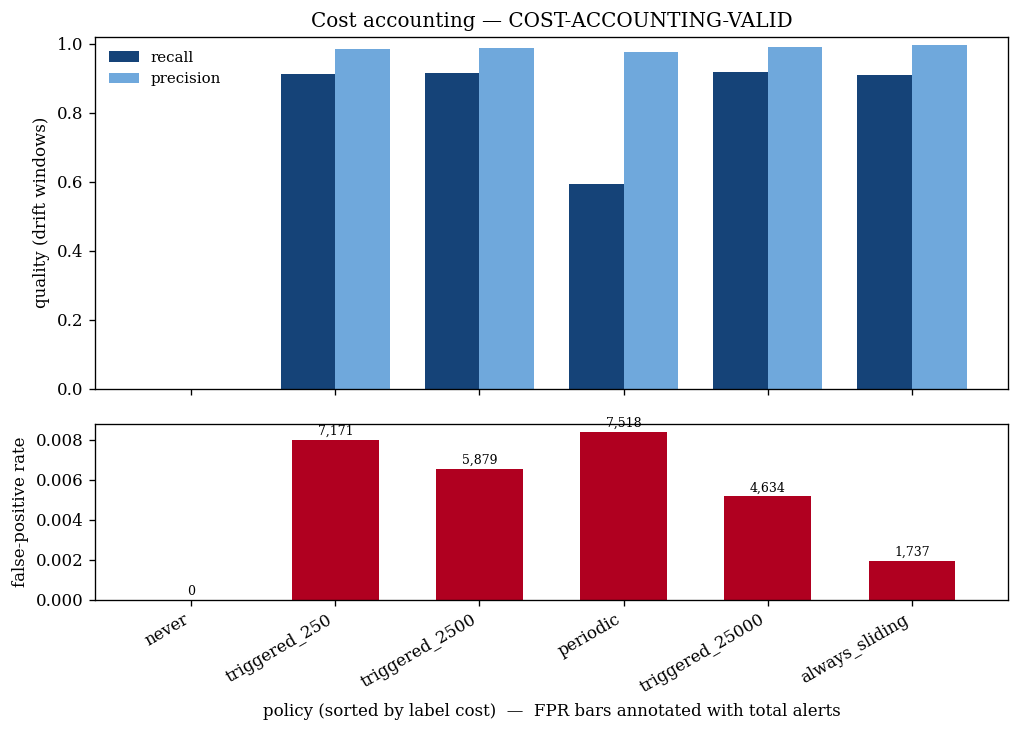

In [6]:
# --- Figure: quality (recall/precision) and false-positive cost (FPR) per policy ---
plt.rcParams.update({'font.family': 'serif', 'font.size': 10,
                     'figure.dpi': 120, 'savefig.dpi': 300})
order = acct['policy'].tolist()
x = np.arange(len(order)); w = 0.38
fig, (axq, axf) = plt.subplots(2, 1, figsize=(8.6, 6.2), sharex=True,
                               gridspec_kw=dict(height_ratios=[2, 1]))
axq.bar(x - w/2, acct['recall'], w, color='#154378', label='recall')
axq.bar(x + w/2, acct['precision'], w, color='#6FA8DC', label='precision')
axq.set_ylabel('quality (drift windows)'); axq.set_ylim(0, 1.02)
axq.legend(frameon=False, fontsize=9); axq.set_title(f'Cost accounting — {verdict}')
axf.bar(x, acct['fpr'], 0.6, color='#B00020')
axf.set_ylabel('false-positive rate')
for xi, (fpr, fp) in enumerate(zip(acct['fpr'], acct['alert_volume_fp'])):
    axf.annotate(f'{int(fp):,}', (xi, fpr), textcoords='offset points',
                 xytext=(0, 3), ha='center', fontsize=7.5)
axf.set_xticks(x); axf.set_xticklabels(order, rotation=30, ha='right')
axf.set_xlabel('policy (sorted by label cost)  —  FPR bars annotated with total alerts')
fig.tight_layout()
path('reports', 'figures').mkdir(parents=True, exist_ok=True)
for ext in ('png', 'pdf'):
    fig.savefig(path('reports', 'figures', f'19_cost_accounting.{ext}'), bbox_inches='tight')
plt.show()

In [7]:
# --- Log decision D037 (idempotent append) and finding F025 ---
dec_path = path('reports', 'advisor_notes', 'decisions_log.md')
dec_path.parent.mkdir(parents=True, exist_ok=True)
dec_lines = [
    '',
    f'## D037 — {date.today()}',
    '**Context:** `07_phase5_adaptation/19_cost_latency`',
    '',
    ('**Decision:** Produce the Objective-7 operational accounting by re-running the nb18 policies '
     'with full confusion-matrix instrumentation (per-window tp/fp/fn/tn, retrain wall-time, '
     'labels), adding the metric nb18 left open: the cheap triggered detector false-positive cost. '
     'Report micro-averaged recall / precision / FPR / F1 over drift windows, total labels, total '
     'compute, and alert volume (total false positives). always_sliding is the full-label '
     'reference that isolates the budget effect on false positives; cumulative is off by default '
     '(RUN_CUMULATIVE). Gates: G1 triggered FPR <= always FPR + 0.05; G2 triggered compute < '
     'always compute; G3 joint (recall within 0.05 of always AND FPR within 0.05 AND labels <= '
     '0.50*always); G4 deterministic. Verdict COST-ACCOUNTING-VALID iff all. Instrumented runner '
     'written to src/adaptation/cost_eval.py; recall reproduces nb18 as a consistency check.'),
    '',
    ('**Rationale:** nb18 showed triggered_250 recovers ~99% of the recall ceiling at 0.48% of the '
     'labelling cost, but measured recall only. A detector trained on ~6,750 flows could trade that '
     'for a high benign false-positive rate, which on millions of flows is the real operator '
     'burden. Objective 7 is the honest completion of the trade-off across all three operational '
     'axes (labels, compute, false positives). Comparing against always_sliding (full labels, same '
     'retrain frequency) isolates whether the small budget itself inflates false positives.'),
    '',
    ('**Alternatives considered:** Cumulative as the FPR reference (rejected as default: 30-min '
     'retrains for a question always_sliding answers; available via RUN_CUMULATIVE). Macro-averaged '
     'rates (rejected: micro-averaging over flows is the operationally correct aggregate; macro '
     'recall is kept only as the nb18 cross-check). Per-window inference latency (negligible vs '
     'retrain wall-time; retrain time is the reported compute/latency). Reporting a single F1 '
     '(rejected: recall, precision and FPR must be shown separately so the trade-off is legible).'),
    '',
]
dec_text = '\n'.join(dec_lines) + '\n'
existing = dec_path.read_text() if dec_path.exists() else ''
if '## D037' in existing:
    print('[DECISION SKIPPED] D037 already logged.')
else:
    with open(dec_path, 'a') as f:
        f.write(dec_text)
    print('[DECISION LOGGED] D037')

log_finding(
    finding_id='F025',
    title='Operational accounting: labels, compute and the cheap detector false-positive cost (Obj 7)',
    what_we_did=(
        'Re-ran the Phase-5 policies with full confusion-matrix instrumentation '
        '(src/adaptation/cost_eval.py, D037) to add the metric nb18 left open -- the triggered '
        'detector false-positive rate and alert volume -- alongside labels and compute, against '
        'always_sliding as the full-label reference.'),
    what_we_found=(
        f'Verdict {verdict}. {headline} Gates G1(FP)={g1_fp}, G2(compute)={g2_compute}, '
        f'G3(joint)={g3_joint}, G4={g4_determ}.'),
    why_it_matters=(
        'Completes the Objective-7 trade-off across all three operational axes. Whether the cheap '
        'triggered detector keeps an acceptable false-positive rate decides if the nb18 recall '
        'headline is operationally real or whether cheap retraining trades labels for alert '
        'burden -- either way the honest cost picture for the thesis. Notebook 20 replicates on UNSW.'),
    context='07_phase5_adaptation/19_cost_latency',
)
print('Done.')

[DECISION LOGGED] D037
[FINDING LOGGED] F025: Operational accounting: labels, compute and the cheap detector false-positive cost (Obj 7)
Done.


## What this notebook establishes

- A reusable instrumented runner in `src/adaptation/cost_eval.py` (full confusion counts +
  retrain time + labels per window).
- The **Objective-7 operational accounting**: recall, precision, **FPR / alert volume**, labels,
  and compute per policy — the honest completion of the nb18 recall-only trade-off.
- A direct answer to the load-bearing question: whether the cheap `triggered` detector keeps an
  acceptable false-positive rate, or trades labels for operator alert burden.

Outputs: `reports/tables/19_cost_accounting.csv`,
`data/processed/phase5_19_cost_latency.json`,
`reports/figures/19_cost_accounting.{png,pdf}`; logs D037 + F025.

**Honest caveats.** FPR here is over CICIDS flows whose benign mix is dataset-specific; the
absolute alert volume will differ on other traffic. "Compute" is retrain wall-time on this CPU
runtime — ordering is robust, absolute seconds are machine-dependent. Latency is dominated by the
structural one-window onset lag (you cannot detect a family before seeing it), not by retrain time.

**Next — notebook 20 (`20_cross_dataset_replication`):** replicate the whole loop (nb16–19) on
UNSW-NB15 — the same harness, trigger, policies and accounting — to show the operational finding
is not CICIDS-specific.